# Comparación Visual de Técnicas de Tokenización para Series Temporales

## Objetivo

Comparar las **6 técnicas de tokenización** identificadas en el Anteproyecto-RITMO sobre los datasets **Electricity** y **ETTh2**.

### Técnicas Comparadas

| # | Técnica | Paper Original | Tipo |
|---|---------|---------------|------|
| 1 | **HMM (Viterbi)** | Tesis RITMO | Estados ocultos de Markov |
| 2 | **SAX** | Lin et al. (2007) | Discretización gaussiana |
| 3 | **LLMTime** | Gruver et al. (2023) | Conversión a texto |
| 4 | **PatchTST** | Nie et al. (2023) | Segmentación en patches |
| 5 | **Autoformer** | Wu et al. (2021) | Descomposición trend-seasonal |
| 6 | **MOMENT** | Goswami et al. (2024) | Masked patches pre-training |

### Datasets Utilizados

- **Electricity**: Consumo eléctrico MT_320 (26,304 timesteps, 321 variables)
- **ETTh2**: Electric Transformer Temperature hourly (17,420 timesteps, 7 variables)

Ambos datasets tienen **cache HMM pre-computado** con diferentes valores de K.

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
import sys
from scipy import stats

# Añadir path del proyecto
sys.path.append('/home/jaime/TFG/RITMO')

# Imports de técnicas de tokenización
from tecnicas import (
    sax_discretize, visualize_sax,
    text_based_tokenize, visualize_text_based,
    patching_tokenize, visualize_patches,
    decomposition_tokenize, visualize_decomposition,
    foundation_tokenize, visualize_foundation
)

# Configuración matplotlib para publicación (estilo académico)
plt.rcParams['figure.figsize'] = (18, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 15
# Tipografía más 'paper-friendly'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
sns.set_style('whitegrid')
# Paleta coherente y accesible (colorblind-friendly)
sns.set_palette('tab10')
# Presets de tamaños reproducibles (single/double column) y utilidades
FIGSIZE_SINGLE = (6.5, 3.5)
FIGSIZE_DOUBLE = (7.5, 4.5)
# Funciones utilitarias reproducibilidad y guardado
def set_seed(seed: int = 42):
    import random; import numpy as _np; import torch as _torch
    random.seed(seed); _np.random.seed(seed);
    try: _torch.manual_seed(seed); _torch.cuda.manual_seed_all(seed)
    except Exception: pass

def savefig(ax_or_fig, fname: str, dpi: int = 300, vector: bool = True):
    import os
    dirpath = (Path.cwd() / 'figures')
    dirpath.mkdir(parents=True, exist_ok=True)
    fullpath = dirpath / fname
    if hasattr(ax_or_fig, 'savefig'):
        ax_or_fig.savefig(fullpath, dpi=dpi, bbox_inches='tight')
    else:
        plt.savefig(fullpath, dpi=dpi, bbox_inches='tight')
    print(f'Figura guardada: {fullpath}')

# Global heatmap vmin/vmax presets (se pueden ajustar por dataset)
GLOBAL_HEAT_VMIN = None
GLOBAL_HEAT_VMAX = None
# Aplicar semilla inicial para reproducibilidad
set_seed(42)

print("[OK] Imports completados")
print(f"Versiones: NumPy {np.__version__}, Pandas {pd.__version__}, Matplotlib {plt.matplotlib.__version__}")

[OK] Imports completados
Versiones: NumPy 2.2.6, Pandas 2.3.3, Matplotlib 3.10.8


In [2]:
# Definir paths
BASE_DIR = Path('/home/jaime/TFG/RITMO')
DATASET_DIR = BASE_DIR / 'dataset'
CACHE_DIR = BASE_DIR / 'cache'

# Cargar cache HMM pre-computado
cache_electricity = pickle.load(open(CACHE_DIR / 'results_electricity.pkl', 'rb'))
cache_etth2 = pickle.load(open(CACHE_DIR / 'results_etth2.pkl', 'rb'))

print("[CACHE HMM]")
print(f"  Electricity: {len(cache_electricity)} configuraciones")
print(f"  ETTh2: {len(cache_etth2)} configuraciones")
print(f"\n[CACHE KEYS] {list(cache_electricity[0].keys())}")

[CACHE HMM]
  Electricity: 42 configuraciones
  ETTh2: 42 configuraciones

[CACHE KEYS] ['K', 'seed', 'data_config', 'train_size', 'revin_success', 'revin_mse', 'hmm_converged', 'hmm_n_iter', 'hmm_checks', 'log_likelihood', 'AIC', 'BIC', 'unique_states', 'n_tokens_llm', 'n_segments', 'compression_ratio', 'avg_segment_duration', 'state_entropy', 'viterbi_checks', 'data_raw', 'data_norm', 'states', 'params']


In [3]:
# Cargar datasets raw (solo para referencia, usaremos datos del cache)
df_electricity = pd.read_csv(DATASET_DIR / 'electricity' / 'electricity.csv')
df_etth2 = pd.read_csv(DATASET_DIR / 'ETT-small' / 'ETTh2.csv')

print("[DATASETS RAW]")
print(f"  Electricity: {df_electricity.shape[0]} timesteps, {df_electricity.shape[1]-1} variables (sin 'date')")
print(f"    - Columnas: {df_electricity.columns.tolist()[:5]} ... (primeras 5)")
print(f"  ETTh2: {df_etth2.shape[0]} timesteps, {df_etth2.shape[1]-1} variables (sin 'date')")
print(f"    - Columnas: {df_etth2.columns.tolist()}")

[DATASETS RAW]
  Electricity: 26304 timesteps, 321 variables (sin 'date')
    - Columnas: ['date', '0', '1', '2', '3'] ... (primeras 5)
  ETTh2: 17420 timesteps, 7 variables (sin 'date')
    - Columnas: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


In [4]:
# Explorar valores de K disponibles
k_values_elec = sorted(set([entry['K'] for entry in cache_electricity]))
k_values_etth2 = sorted(set([entry['K'] for entry in cache_etth2]))

print("[VALORES K DISPONIBLES]")
print(f"  Electricity: {k_values_elec}")
print(f"  ETTh2: {k_values_etth2}")

# Seleccionar K=5
K_SELECTED = 5

# Buscar entrada correspondiente a K=5
hmm_elec = [e for e in cache_electricity if e['K'] == K_SELECTED][0]
hmm_etth2 = [e for e in cache_etth2 if e['K'] == K_SELECTED][0]

print(f"\n[CONFIGURACIÓN SELECCIONADA: K={K_SELECTED}]")
print("\nElectricity:")
print(f"  - Convergencia: {hmm_elec['hmm_converged']}")
print(f"  - Iteraciones EM: {hmm_elec['hmm_n_iter']}")
print(f"  - Log-likelihood: {hmm_elec['log_likelihood']:.2f}")
print(f"  - AIC: {hmm_elec['AIC']:.2f}")
print(f"  - BIC: {hmm_elec['BIC']:.2f}")
print(f"  - Compression Ratio: {hmm_elec['compression_ratio']:.2f}")
print(f"  - Entropía Estados: {hmm_elec['state_entropy']:.3f}")

print("\nETTh2:")
print(f"  - Convergencia: {hmm_etth2['hmm_converged']}")
print(f"  - Iteraciones EM: {hmm_etth2['hmm_n_iter']}")
print(f"  - Log-likelihood: {hmm_etth2['log_likelihood']:.2f}")
print(f"  - AIC: {hmm_etth2['AIC']:.2f}")
print(f"  - BIC: {hmm_etth2['BIC']:.2f}")
print(f"  - Compression Ratio: {hmm_etth2['compression_ratio']:.2f}")
print(f"  - Entropía Estados: {hmm_etth2['state_entropy']:.3f}")

[VALORES K DISPONIBLES]
  Electricity: [3, 4, 5, 6, 7, 8, 9]
  ETTh2: [3, 4, 5, 6, 7, 8, 9]

[CONFIGURACIÓN SELECCIONADA: K=5]

Electricity:
  - Convergencia: True
  - Iteraciones EM: 177
  - Log-likelihood: -10461.81
  - AIC: 20993.61
  - BIC: 21267.34
  - Compression Ratio: 6.45
  - Entropía Estados: 1.583

ETTh2:
  - Convergencia: True
  - Iteraciones EM: 53
  - Log-likelihood: -1833.09
  - AIC: 3736.19
  - BIC: 3983.43
  - Compression Ratio: 16.43
  - Entropía Estados: 1.603


In [5]:
# Extraer series normalizadas y estados del cache
# ELECTRICITY
elec_data_norm = hmm_elec['data_norm']  # Serie normalizada con RevIN
elec_states = hmm_elec['states']  # Estados Viterbi (secuencia óptima)
elec_params = hmm_elec['params']  # Parámetros HMM: {A, pi, mu, sigma}

# ETTh2
etth2_data_norm = hmm_etth2['data_norm']
etth2_states = hmm_etth2['states']
etth2_params = hmm_etth2['params']

print("[DATOS EXTRAÍDOS DEL CACHE]")
print(f"\nElectricity:")
print(f"  - Serie normalizada: {len(elec_data_norm)} timesteps")
print(f"  - Estados Viterbi: {len(elec_states)} tokens")
print(f"  - Estados únicos usados: {len(np.unique(elec_states))} / {K_SELECTED}")
print(f"  - Parámetros HMM:")
print(f"      mu (medias): {elec_params['mu']}")
print(f"      sigma (std): {elec_params['sigma']}")

print(f"\nETTh2:")
print(f"  - Serie normalizada: {len(etth2_data_norm)} timesteps")
print(f"  - Estados Viterbi: {len(etth2_states)} tokens")
print(f"  - Estados únicos usados: {len(np.unique(etth2_states))} / {K_SELECTED}")
print(f"  - Parámetros HMM:")
print(f"      mu (medias): {etth2_params['mu']}")
print(f"      sigma (std): {etth2_params['sigma']}")

[DATOS EXTRAÍDOS DEL CACHE]

Electricity:
  - Serie normalizada: 18412 timesteps
  - Estados Viterbi: 18412 tokens
  - Estados únicos usados: 5 / 5
  - Parámetros HMM:
      mu (medias): [-0.72981995  0.51625283 -0.1039296  -1.28926035  1.70443694]
      sigma (std): [0.19365815 0.25434948 0.22212615 0.21680156 0.76668403]

ETTh2:
  - Serie normalizada: 8640 timesteps
  - Estados Viterbi: 8640 tokens
  - Estados únicos usados: 5 / 5
  - Parámetros HMM:
      mu (medias): [-0.13346396  1.42356159 -1.38693213  0.53497013 -0.82461555]
      sigma (std): [0.20121107 0.38832149 0.22157581 0.22249028 0.18249821]


In [6]:
N_TIMESTEPS = 1500

# Electricity
elec_series = elec_data_norm[:N_TIMESTEPS]
elec_states_vis = elec_states[:N_TIMESTEPS]

# ETTh2
etth2_series = etth2_data_norm[:N_TIMESTEPS]
etth2_states_vis = etth2_states[:N_TIMESTEPS]

print(f"[VENTANA DE VISUALIZACIÓN]")
print(f"  Timesteps seleccionados: {N_TIMESTEPS}")
print(f"  Porcentaje de serie completa:")
print(f"    - Electricity: {N_TIMESTEPS/len(elec_data_norm)*100:.1f}%")
print(f"    - ETTh2: {N_TIMESTEPS/len(etth2_data_norm)*100:.1f}%")

[VENTANA DE VISUALIZACIÓN]
  Timesteps seleccionados: 1500
  Porcentaje de serie completa:
    - Electricity: 8.1%
    - ETTh2: 17.4%


In [7]:
print("[TOKENIZANDO ELECTRICITY]")

# SAX - Discretización con alfabeto de 8 símbolos
elec_sax = sax_discretize(elec_series, alphabet_size=8)
print(f"  SAX: {elec_sax['vocabulary_size']} símbolos, {elec_sax['num_tokens']} tokens")

# LLMTime - Conversión a texto base-10 con 2 decimales
elec_text = text_based_tokenize(elec_series, base=10, precision=2)
print(f"  LLMTime: {elec_text['num_tokens']} caracteres, vocabulario={elec_text['vocabulary_size']}")

# PatchTST - Segmentación en patches de 16 timesteps sin solapamiento
elec_patch_array = patching_tokenize(elec_series, patch_len=16, stride=16)
elec_patch = visualize_patches(elec_series, elec_patch_array, 16, 16)
print(f"  PatchTST: {elec_patch['num_patches']} patches, CR={elec_patch['compression_ratio']:.2f}")

# Autoformer - Descomposición trend-seasonal con ventana móvil=25
elec_decomp = decomposition_tokenize(elec_series, kernel_size=25)
print(f"  Autoformer: {elec_decomp['num_tokens']} componentes (trend + seasonal)")

# MOMENT - Masked patches con 30% enmascarado
elec_foundation = foundation_tokenize(elec_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {elec_foundation['num_patches']} patches, {elec_foundation['num_masked']} masked ({elec_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[TOKENIZANDO ETTh2]")

etth2_sax = sax_discretize(etth2_series, alphabet_size=8)
print(f"  SAX: {etth2_sax['vocabulary_size']} símbolos, {etth2_sax['num_tokens']} tokens")

etth2_text = text_based_tokenize(etth2_series, base=10, precision=2)
print(f"  LLMTime: {etth2_text['num_tokens']} caracteres, vocabulario={etth2_text['vocabulary_size']}")

etth2_patch_array = patching_tokenize(etth2_series, patch_len=16, stride=16)
etth2_patch = visualize_patches(etth2_series, etth2_patch_array, 16, 16)
print(f"  PatchTST: {etth2_patch['num_patches']} patches, CR={etth2_patch['compression_ratio']:.2f}")

etth2_decomp = decomposition_tokenize(etth2_series, kernel_size=25)
print(f"  Autoformer: {etth2_decomp['num_tokens']} componentes (trend + seasonal)")

etth2_foundation = foundation_tokenize(etth2_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {etth2_foundation['num_patches']} patches, {etth2_foundation['num_masked']} masked ({etth2_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[OK] Todas las técnicas aplicadas")

[TOKENIZANDO ELECTRICITY]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15826 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[TOKENIZANDO ETTh2]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15024 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[OK] Todas las técnicas aplicadas


In [8]:
def create_comparison_table(dataset_name, series_len, hmm_result, hmm_states_vis, sax, text, patch, decomp, foundation):
    """Crear tabla comparativa de métricas de tokenización."""
    # Para HMM: Vocabulary Size = K (5 estados únicos)
    # Num Tokens = número de segmentos en la ventana visible
    # Compression Ratio = serie_len / num_segmentos
    num_segments_vis = np.sum(np.diff(np.concatenate([[hmm_states_vis[0]], hmm_states_vis])) != 0)
    cr_vis = series_len / num_segments_vis if num_segments_vis > 0 else series_len

    data = [
        {
            'Técnica': 'HMM (Viterbi)',
            'Num Tokens (Segmentos)': num_segments_vis,  # CORREGIDO: número de segmentos
            'Compression Ratio': cr_vis,  # CORREGIDO: CR sobre ventana visible
            'Vocabulary Size': hmm_result['K'],  # K=5 estados
            'Tipo': 'Probabilístico',
            'Paper': 'Tesis RITMO (2025)'
        },
        {
            'Técnica': 'SAX',
            'Num Tokens (Segmentos)': sax['num_tokens'],
            'Compression Ratio': sax['compression_ratio'],
            'Vocabulary Size': sax['vocabulary_size'],
            'Tipo': 'Discreto',
            'Paper': 'Lin et al. (2007)'
        },
        {
            'Técnica': 'LLMTime',
            'Num Tokens (Segmentos)': text['num_tokens'],
            'Compression Ratio': text['compression_ratio'],
            'Vocabulary Size': text['vocabulary_size'],
            'Tipo': 'Textual',
            'Paper': 'Gruver et al. (2023)'
        },
        {
            'Técnica': 'PatchTST',
            'Num Tokens (Segmentos)': patch['num_patches'],
            'Compression Ratio': patch['compression_ratio'],
            'Vocabulary Size': 'Continuo',
            'Tipo': 'Segmentación',
            'Paper': 'Nie et al. (2023)'
        },
        {
            'Técnica': 'Autoformer',
            'Num Tokens (Segmentos)': decomp['num_tokens'],
            'Compression Ratio': decomp['compression_ratio'],
            'Vocabulary Size': '2 componentes',
            'Tipo': 'Descomposición',
            'Paper': 'Wu et al. (2021)'
        },
        {
            'Técnica': 'MOMENT',
            'Num Tokens (Segmentos)': foundation['num_patches'],
            'Compression Ratio': foundation['compression_ratio'],
            'Vocabulary Size': f"{foundation['num_masked']} masked",
            'Tipo': 'Pre-training',
            'Paper': 'Goswami et al. (2024)'
        }
    ]
    
    df = pd.DataFrame(data)
    df['Dataset'] = dataset_name
    df['Serie Length'] = series_len
    return df

# Crear tablas - PASAR elec_states_vis y etth2_states_vis
table_elec = create_comparison_table('Electricity', len(elec_series), hmm_elec, elec_states_vis,
                                      elec_sax, elec_text, elec_patch, elec_decomp, elec_foundation)
table_etth2 = create_comparison_table('ETTh2', len(etth2_series), hmm_etth2, etth2_states_vis,
                                       etth2_sax, etth2_text, etth2_patch, etth2_decomp, etth2_foundation)

# Combinar
table_combined = pd.concat([table_elec, table_etth2], ignore_index=True)

print("="*120)
print("TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN")
print("="*120)
print(table_combined.to_string(index=False))
print("="*120)

TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN
      Técnica  Num Tokens (Segmentos)  Compression Ratio Vocabulary Size           Tipo                 Paper     Dataset  Serie Length
HMM (Viterbi)                     223           6.726457               5 Probabilístico    Tesis RITMO (2025) Electricity          1500
          SAX                    1500           1.000000               8       Discreto     Lin et al. (2007) Electricity          1500
      LLMTime                   15826           0.094781              13        Textual  Gruver et al. (2023) Electricity          1500
     PatchTST                      93          16.129032        Continuo   Segmentación     Nie et al. (2023) Electricity          1500
   Autoformer                       2         750.000000   2 componentes Descomposición      Wu et al. (2021) Electricity          1500
       MOMENT                      93          16.129032       28 masked   Pre-training Goswami et al. (2024) Electricity          1500
HM

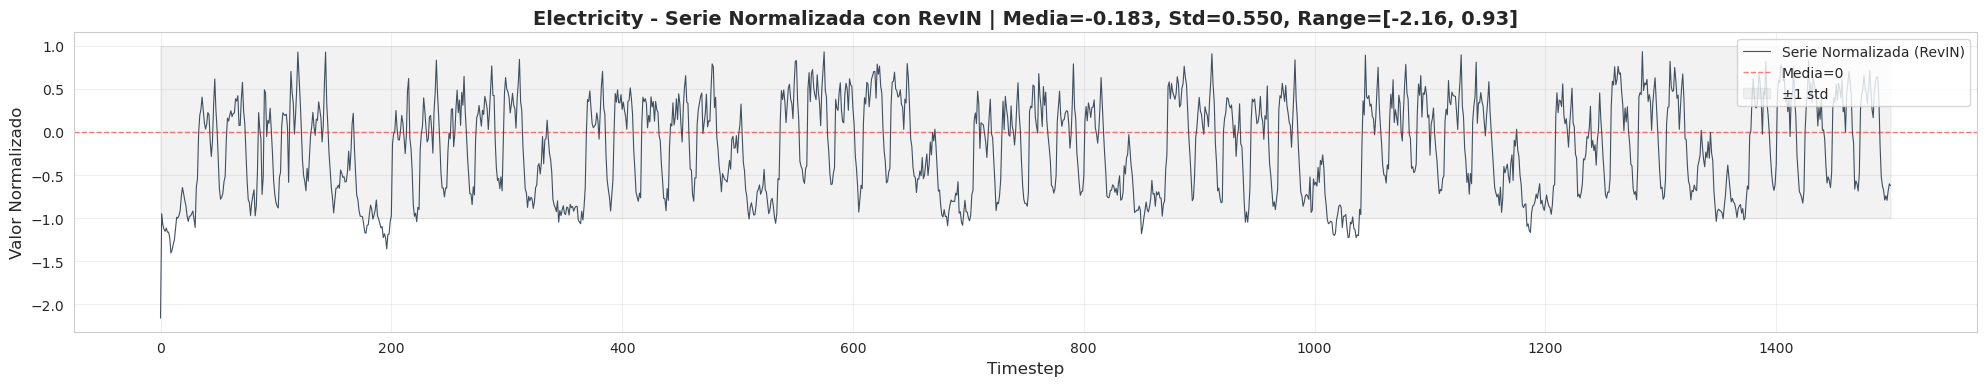

[ESTADÍSTICAS SERIE NORMALIZADA]
  Media: -0.183307 (debe estar cerca de 0)
  Desviación estándar: 0.549546 (debe estar cerca de 1)
  Min: -2.163, Max: 0.934
  Rango: 3.097


In [ ]:
# 7.1 Serie Original Normalizada
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(etth2_series, linewidth=0.8, color='#2C3E50', alpha=0.9, label='Serie Normalizada (RevIN)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Media=0')
ax.fill_between(range(len(etth2_series)), -1, 1, alpha=0.1, color='gray', label='±1 std')

mean_val = etth2_series.mean()
std_val = etth2_series.std()
min_val = etth2_series.min()
max_val = etth2_series.max()

ax.set_title(f'ETTh2 - Serie Normalizada con RevIN | Media={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.2f}, {max_val:.2f}]', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Valor Normalizado', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[ESTADÍSTICAS SERIE NORMALIZADA]")
print(f"  Media: {mean_val:.6f} (debe estar cerca de 0)")
print(f"  Desviación estándar: {std_val:.6f} (debe estar cerca de 1)")
print(f"  Min: {min_val:.3f}, Max: {max_val:.3f}")
print(f"  Rango: {max_val - min_val:.3f}")